In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.listdir('/content/drive/MyDrive/Colab')

['placement_dataset.csv',
 'placement_predict_50k Dataset (1) (1).csv',
 'placement_predict_50k_adjusted.csv',
 'age_insurance.csv',
 'simple_placement_dataset.csv',
 'movies_dataset(1).csv',
 'WineQT.csv',
 'WineQT_Feature_Engineered.csv',
 'placement_predict_50k_adjusted (1).csv',
 'student_data.csv',
 'xgboost_lightgbm_shap_student_dataset.csv',
 'iris_dataset.csv',
 'breast_cancer_classification_dataset (1).csv',
 'mall_customers_clustering_dataset.csv',
 'digits_pca_tsne_umap_dataset.csv',
 'isolation_forest_dataset.csv',
 'socioeconomic_profiling_dataset.csv',
 'ml_cross_validation_calibration_dataset.csv',
 'hyperparameter_tuning_dataset.csv',
 'evaluation_threshold_calibration_dataset.csv',
 'student_performance.csv',
 'student_performance_mlops.csv']

In [3]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab/placement_dataset.csv')



END-TO-END MLOPS PIPELINE
Batch Scoring + PSI + Retraining

STEP 1: LOADING TRAINING DATA
Dataset loaded successfully.
Rows: 400
Columns: 9

First 5 records:
   study_hours  attendance  previous_score  assignments_completed  \
0         3.62       59.64           78.90                      8   
1         7.66       95.61           48.39                      2   
2         6.12       77.74           71.70                      7   
3         5.19       92.19           73.37                      4   
4         2.09       69.40           63.33                      8   

   sleep_hours  internet_access  extracurricular  final_score  pass  
0         8.11                0                0        65.48     1  
1         6.12                1                1        75.41     1  
2         7.34                1                0        80.31     1  
3         4.48                0                0        66.01     1  
4         7.12                0                0        65.52     1  

STEP

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


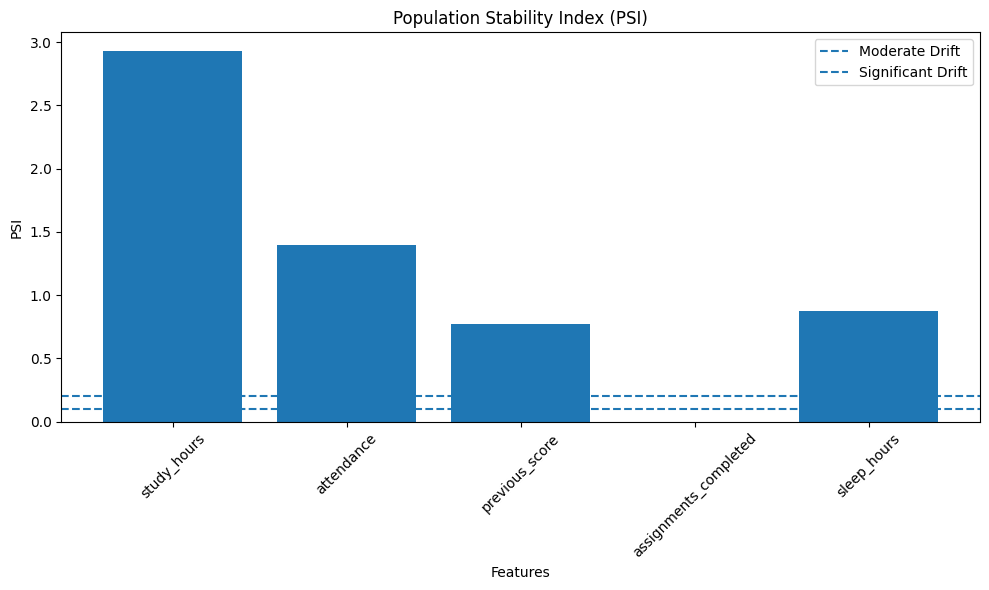


STEP 6: DRIFT DECISION
Maximum PSI: 2.9307
PSI Threshold: 0.2

SIGNIFICANT DRIFT DETECTED!
Retraining is required.

STEP 7: MODEL RETRAINING
Retrained model saved:
models/student_model_retrained.pkl

Retraining completed successfully.

MLOPS PIPELINE COMPLETED

Generated files:
1. data/production_data.csv
2. data/batch_predictions.csv
3. data/psi_report.csv
4. data/psi_monitoring.png
5. models/student_model.pkl
6. models/student_model_retrained.pkl

End-to-End MLOps process completed!


In [5]:
# ============================================================
# END-TO-END MLOps PROJECT
#
# Batch Scoring + PSI Monitoring + Retraining Pipeline
#
# Project:
# Student Performance Prediction
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report


# ============================================================
# 1. CONFIGURATION
# ============================================================

TRAIN_DATA = "/content/drive/MyDrive/Colab/student_performance_mlops.csv"

PRODUCTION_DATA = "data/production_data.csv"

MODEL_FILE = "models/student_model.pkl"

BATCH_OUTPUT = "data/batch_predictions.csv"

PSI_REPORT = "data/psi_report.csv"


FEATURES = [
    "study_hours",
    "attendance",
    "previous_score",
    "assignments_completed",
    "sleep_hours",
    "internet_access",
    "extracurricular"
]

TARGET = "pass"


# PSI threshold
# PSI > 0.20 indicates significant population change
PSI_THRESHOLD = 0.20


# ============================================================
# 2. CREATE FOLDERS
# ============================================================

def create_folders():

    os.makedirs(
        "data",
        exist_ok=True
    )

    os.makedirs(
        "models",
        exist_ok=True
    )


# ============================================================
# 3. LOAD TRAINING DATA
# ============================================================

def load_training_data():

    print("\n" + "=" * 60)
    print("STEP 1: LOADING TRAINING DATA")
    print("=" * 60)

    df = pd.read_csv(
        TRAIN_DATA
    )

    print("Dataset loaded successfully.")

    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])

    print("\nFirst 5 records:")
    print(df.head())

    return df


# ============================================================
# 4. CREATE MACHINE LEARNING MODEL
# ============================================================

def create_model():

    model = Pipeline([

        (
            "scaler",
            StandardScaler()
        ),

        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ])

    return model


# ============================================================
# 5. TRAIN MODEL
# ============================================================

def train_model(df):

    print("\n" + "=" * 60)
    print("STEP 2: TRAINING MODEL")
    print("=" * 60)

    X = df[FEATURES]

    y = df[TARGET]

    X_train, X_test, y_train, y_test = train_test_split(

        X,
        y,

        test_size=0.20,

        random_state=42,

        stratify=y
    )

    model = create_model()

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_test
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    print("\nModel Accuracy:")
    print(accuracy)

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            predictions
        )
    )

    # Save model

    joblib.dump(
        model,
        MODEL_FILE
    )

    print("\nModel saved to:")
    print(MODEL_FILE)

    return model


# ============================================================
# 6. CREATE PRODUCTION DATA
# ============================================================

def create_production_data(df):

    print("\n" + "=" * 60)
    print("STEP 3: CREATING PRODUCTION DATA")
    print("=" * 60)

    production = df.copy()

    # --------------------------------------------------------
    # Simulate real-world data distribution change
    # --------------------------------------------------------

    # Students study fewer hours
    production["study_hours"] = (
        production["study_hours"] * 0.65
    )

    # Attendance decreases
    production["attendance"] = (
        production["attendance"] - 10
    )

    # Previous scores decrease
    production["previous_score"] = (
        production["previous_score"] - 7
    )

    # Sleep hours decrease
    production["sleep_hours"] = (
        production["sleep_hours"] - 1
    )

    # Keep values realistic

    production["study_hours"] = production[
        "study_hours"
    ].clip(0, 8)

    production["attendance"] = production[
        "attendance"
    ].clip(0, 100)

    production["previous_score"] = production[
        "previous_score"
    ].clip(0, 100)

    production["sleep_hours"] = production[
        "sleep_hours"
    ].clip(0, 12)

    # Save production dataset

    production.to_csv(
        PRODUCTION_DATA,
        index=False
    )

    print(
        "Production data created:"
    )

    print(
        PRODUCTION_DATA
    )

    return production


# ============================================================
# 7. BATCH SCORING
# ============================================================

def batch_scoring(model, production):

    print("\n" + "=" * 60)
    print("STEP 4: BATCH SCORING")
    print("=" * 60)

    X_production = production[
        FEATURES
    ]

    # Predict
    predictions = model.predict(
        X_production
    )

    # Prediction probability
    probabilities = model.predict_proba(
        X_production
    )

    # Add predictions to dataset

    results = production.copy()

    results[
        "predicted_pass"
    ] = predictions

    results[
        "pass_probability"
    ] = probabilities[:, 1]

    # Convert 0/1 to text

    results[
        "prediction_result"
    ] = results[
        "predicted_pass"
    ].map({
        0: "FAIL",
        1: "PASS"
    })

    # Save results

    results.to_csv(
        BATCH_OUTPUT,
        index=False
    )

    print(
        "Batch scoring completed."
    )

    print(
        "Output file:",
        BATCH_OUTPUT
    )

    print("\nSample predictions:")

    print(
        results[
            [
                "predicted_pass",
                "pass_probability",
                "prediction_result"
            ]
        ].head(10)
    )

    return results


# ============================================================
# 8. PSI CALCULATION FUNCTION
# ============================================================

def calculate_psi(
    expected,
    actual,
    bins=10
):

    # Remove missing values

    expected = np.array(
        expected.dropna()
    )

    actual = np.array(
        actual.dropna()
    )

    # Create bins based on training data

    breakpoints = np.percentile(
        expected,
        np.linspace(
            0,
            100,
            bins + 1
        )
    )

    # Remove duplicate breakpoints

    breakpoints = np.unique(
        breakpoints
    )

    # If there are not enough bins

    if len(breakpoints) < 3:

        return 0.0

    # Calculate expected distribution

    expected_counts = np.histogram(
        expected,
        bins=breakpoints
    )[0]

    # Calculate actual distribution

    actual_counts = np.histogram(
        actual,
        bins=breakpoints
    )[0]

    # Convert to percentages

    expected_percent = (
        expected_counts
        / len(expected)
    )

    actual_percent = (
        actual_counts
        / len(actual)
    )

    # Avoid zero values

    expected_percent = np.where(
        expected_percent == 0,
        0.0001,
        expected_percent
    )

    actual_percent = np.where(
        actual_percent == 0,
        0.0001,
        actual_percent
    )

    # PSI formula

    psi = np.sum(

        (
            actual_percent
            - expected_percent
        )

        *

        np.log(
            actual_percent
            / expected_percent
        )
    )

    return psi


# ============================================================
# 9. PSI MONITORING
# ============================================================

def calculate_psi_report(
    training_data,
    production_data
):

    print("\n" + "=" * 60)
    print("STEP 5: PSI MONITORING")
    print("=" * 60)

    results = []

    numeric_features = [
        "study_hours",
        "attendance",
        "previous_score",
        "assignments_completed",
        "sleep_hours"
    ]

    for feature in numeric_features:

        psi_value = calculate_psi(

            training_data[
                feature
            ],

            production_data[
                feature
            ]
        )

        if psi_value < 0.10:

            status = "NO DRIFT"

        elif psi_value < 0.20:

            status = "MODERATE DRIFT"

        else:

            status = "SIGNIFICANT DRIFT"

        results.append({

            "feature": feature,

            "PSI": round(
                psi_value,
                4
            ),

            "status": status
        })

    report = pd.DataFrame(
        results
    )

    print("\nPSI Report:")
    print(report)

    report.to_csv(
        PSI_REPORT,
        index=False
    )

    return report


# ============================================================
# 10. CHECK WHETHER RETRAINING IS REQUIRED
# ============================================================

def check_retraining(psi_report):

    print("\n" + "=" * 60)
    print("STEP 6: DRIFT DECISION")
    print("=" * 60)

    maximum_psi = psi_report[
        "PSI"
    ].max()

    print(
        "Maximum PSI:",
        maximum_psi
    )

    print(
        "PSI Threshold:",
        PSI_THRESHOLD
    )

    if maximum_psi >= PSI_THRESHOLD:

        print(
            "\nSIGNIFICANT DRIFT DETECTED!"
        )

        print(
            "Retraining is required."
        )

        return True

    else:

        print(
            "\nNo significant drift detected."
        )

        print(
            "Retraining is not required."
        )

        return False


# ============================================================
# 11. RETRAIN MODEL
# ============================================================

def retrain_model(
    training_data,
    production_data
):

    print("\n" + "=" * 60)
    print("STEP 7: MODEL RETRAINING")
    print("=" * 60)

    # Combine old and new production data

    combined_data = pd.concat(

        [
            training_data,
            production_data
        ],

        ignore_index=True
    )

    X = combined_data[
        FEATURES
    ]

    y = combined_data[
        TARGET
    ]

    # Create new model

    new_model = create_model()

    # Train

    new_model.fit(
        X,
        y
    )

    # Save new model

    new_model_file = (
        "models/student_model_retrained.pkl"
    )

    joblib.dump(
        new_model,
        new_model_file
    )

    print(
        "Retrained model saved:"
    )

    print(
        new_model_file
    )

    return new_model


# ============================================================
# 12. VISUALIZE PSI
# ============================================================

def visualize_psi(
    psi_report
):

    print("\n" + "=" * 60)
    print("STEP 8: PSI VISUALIZATION")
    print("=" * 60)

    plt.figure(
        figsize=(10, 6)
    )

    plt.bar(
        psi_report["feature"],
        psi_report["PSI"]
    )

    plt.axhline(
        y=0.10,
        linestyle="--",
        label="Moderate Drift"
    )

    plt.axhline(
        y=0.20,
        linestyle="--",
        label="Significant Drift"
    )

    plt.xlabel(
        "Features"
    )

    plt.ylabel(
        "PSI"
    )

    plt.title(
        "Population Stability Index (PSI)"
    )

    plt.xticks(
        rotation=45
    )

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        "data/psi_monitoring.png"
    )

    plt.show()


# ============================================================
# 13. MAIN MLOPS PIPELINE
# ============================================================

if __name__ == "__main__":

    print("\n")
    print("=" * 60)
    print("END-TO-END MLOPS PIPELINE")
    print("Batch Scoring + PSI + Retraining")
    print("=" * 60)

    # --------------------------------------------------------
    # Create folders
    # --------------------------------------------------------

    create_folders()

    # --------------------------------------------------------
    # Load training data
    # --------------------------------------------------------

    training_data = load_training_data()

    # --------------------------------------------------------
    # Train initial model
    # --------------------------------------------------------

    model = train_model(
        training_data
    )

    # --------------------------------------------------------
    # Create simulated production data
    # --------------------------------------------------------

    production_data = (
        create_production_data(
            training_data
        )
    )

    # --------------------------------------------------------
    # Batch scoring
    # --------------------------------------------------------

    batch_results = batch_scoring(
        model,
        production_data
    )

    # --------------------------------------------------------
    # Calculate PSI
    # --------------------------------------------------------

    psi_report = calculate_psi_report(

        training_data,

        production_data
    )

    # --------------------------------------------------------
    # Visualize PSI
    # --------------------------------------------------------

    visualize_psi(
        psi_report
    )

    # --------------------------------------------------------
    # Check drift
    # --------------------------------------------------------

    retraining_required = (
        check_retraining(
            psi_report
        )
    )

    # --------------------------------------------------------
    # Retrain if drift detected
    # --------------------------------------------------------

    if retraining_required:

        retrained_model = retrain_model(

            training_data,

            production_data
        )

        print(
            "\nRetraining completed successfully."
        )

    else:

        print(
            "\nNo retraining required."
        )

    # --------------------------------------------------------
    # Final output
    # --------------------------------------------------------

    print("\n" + "=" * 60)
    print("MLOPS PIPELINE COMPLETED")
    print("=" * 60)

    print(
        "\nGenerated files:"
    )

    print(
        "1. data/production_data.csv"
    )

    print(
        "2. data/batch_predictions.csv"
    )

    print(
        "3. data/psi_report.csv"
    )

    print(
        "4. data/psi_monitoring.png"
    )

    print(
        "5. models/student_model.pkl"
    )

    if retraining_required:

        print(
            "6. models/student_model_retrained.pkl"
        )

    print(
        "\nEnd-to-End MLOps process completed!"
    )
